In [2]:
# ============================================================
# CELL 1 — IMPORTS
# ============================================================

import re
import json
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder

pd.set_option("display.max_columns", None)

print("Libraries loaded successfully.")


Libraries loaded successfully.


In [3]:
# ============================================================
# CELL 2 — LOAD CLEAN DATASET
# ============================================================

DATASET_PATH = "../../parquet_exports_v2/retrieval_clean_ready_v2.parquet"

df = pd.read_parquet(DATASET_PATH)

print("=" * 60)
print("DATASET LOADED")
print("=" * 60)

print(f"Rows    : {len(df):,}")
print(f"Columns : {df.shape[1]}")

df.head()


DATASET LOADED
Rows    : 108,421
Columns : 31


,rag_id,problem_text_clean,solution_text_clean,category,priority,language,product,queue,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,is_sla_breached,is_escalated,escalation_risk_level,issue_complexity_score,sla_risk_score,problem_word_count,problem_char_count,problem_repetition_ratio,solution_word_count,solution_char_count,solution_repetition_ratio,source_system,source_dataset,created_at,resolved_at
0,45d0726cc395d2b3a2b8c9899523e1dc,i am unable to access my account after enterin...,security settings updated and customer notifie...,performance issue,critical,french,Subscription Service,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,low,4.0,3.75,24,145,0.5,9,74,0.0,customer_support_tickets_200k,customer_support_tickets_200k,2022-09-08,2022-09-08
1,504f35fd3b03f048a1984f89fffb08e1,i would like to request a refund for the recen...,explained billing breakdown and clarified appl...,login issue,medium,french,E-commerce Store,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,low,2.0,2.80,22,111,0.5,7,61,0.0,customer_support_tickets_200k,customer_support_tickets_200k,2023-09-25,2023-09-28
2,db7bc1e2f75fa986ee832c31e320a2de,there seems to be a discrepancy in my billing ...,provided step-by-step troubleshooting instruct...,refund request,high,english,Cloud Storage,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,low,7.0,4.00,26,143,0.5,7,70,0.0,customer_support_tickets_200k,customer_support_tickets_200k,2023-06-21,2023-06-21
3,01d7f2addbcc200f88368695230ea06e,the system is not syncing data across devices ...,bug logged internally and workaround shared wi...,payment problem,low,chinese,Analytics Dashboard,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,low,6.0,2.95,18,111,0.5,9,62,0.0,customer_support_tickets_200k,customer_support_tickets_200k,2023-03-13,2023-03-25
4,aa219338e9e467aadb53d3d1a9026de7,i am unable to access my account after enterin...,provided step-by-step troubleshooting instruct...,security concern,low,german,Cloud Storage,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,low,7.0,3.30,24,145,0.5,7,70,0.0,customer_support_tickets_200k,customer_support_tickets_200k,2024-10-12,2024-10-21


In [4]:
# ============================================================
# CELL 3 — BASIC TEXT FEATURES
# ============================================================

# Average word length — problem
df["problem_avg_word_length"] = (
    df["problem_text_clean"]
    .apply(
        lambda x: np.mean(
            [len(word) for word in str(x).split()]
        ) if str(x).split() else 0
    )
)

# Unique word ratio — problem
df["problem_unique_word_ratio"] = (
    df["problem_text_clean"]
    .apply(
        lambda x: (
            len(set(str(x).split())) / len(str(x).split())
        ) if str(x).split() else 0
    )
)

# Average word length — solution
df["solution_avg_word_length"] = (
    df["solution_text_clean"]
    .apply(
        lambda x: np.mean(
            [len(word) for word in str(x).split()]
        ) if str(x).split() else 0
    )
)

# Unique word ratio — solution
df["solution_unique_word_ratio"] = (
    df["solution_text_clean"]
    .apply(
        lambda x: (
            len(set(str(x).split())) / len(str(x).split())
        ) if str(x).split() else 0
    )
)

print("Basic NLP features created.")

df[
    [
        "problem_avg_word_length",
        "problem_unique_word_ratio",
        "solution_avg_word_length",
        "solution_unique_word_ratio"
    ]
].head()


Basic NLP features created.


,problem_avg_word_length,problem_unique_word_ratio,solution_avg_word_length,solution_unique_word_ratio
0,5.083333,0.5,7.333333,1.0
1,4.090909,0.5,7.857143,1.0
2,4.538462,0.5,9.142857,1.0
3,5.222222,0.5,6.000000,1.0
4,5.083333,0.5,9.142857,1.0


In [5]:
# ============================================================
# CELL 4 — UPPERCASE RATIO
# ============================================================

def uppercase_ratio(text: str) -> float:

    text = str(text)

    if len(text) == 0:
        return 0.0

    uppercase_chars = sum(1 for c in text if c.isupper())

    return uppercase_chars / len(text)


df["problem_uppercase_ratio"] = (
    df["problem_text_clean"]
    .apply(uppercase_ratio)
)

df["solution_uppercase_ratio"] = (
    df["solution_text_clean"]
    .apply(uppercase_ratio)
)

print("uppercase_ratio features created.")


uppercase_ratio features created.


In [6]:
# ============================================================
# CELL 5 — DIGIT RATIO
# ============================================================

def digit_ratio(text: str) -> float:

    text = str(text)

    if len(text) == 0:
        return 0.0

    digits = sum(1 for c in text if c.isdigit())

    return digits / len(text)


df["problem_digit_ratio"] = (
    df["problem_text_clean"]
    .apply(digit_ratio)
)

df["solution_digit_ratio"] = (
    df["solution_text_clean"]
    .apply(digit_ratio)
)

print("digit_ratio features created.")


digit_ratio features created.


In [7]:
# ============================================================
# CELL 6 — SPECIAL CHARACTER RATIO
# ============================================================

def special_char_ratio(text: str) -> float:

    text = str(text)

    if len(text) == 0:
        return 0.0

    special_chars = len(
        re.findall(r"[^a-zA-Z0-9\s]", text)
    )

    return special_chars / len(text)

df["problem_special_char_ratio"] = (
    df["problem_text_clean"]
    .apply(special_char_ratio)
)

df["solution_special_char_ratio"] = (
    df["solution_text_clean"]
    .apply(special_char_ratio)
)

print("special_char_ratio features created.")


special_char_ratio features created.


In [8]:
# ============================================================
# CELL 7 — SOURCE SYSTEM ENCODING
# ============================================================

if "source_system" in df.columns:

    encoder = LabelEncoder()

    df["source_system_encoded"] = (
        encoder.fit_transform(
            df["source_system"].astype(str)
        )
    )

    print("source_system encoded successfully.")

    encoding_mapping = dict(
        zip(
            encoder.classes_,
            encoder.transform(encoder.classes_)
        )
    )

    print("\nEncoding Mapping:")
    print(encoding_mapping)


source_system encoded successfully.

Encoding Mapping:
{'customer_support_tickets_200k': np.int64(0), 'dataset_tickets_multi_lang': np.int64(1)}


In [9]:
# ============================================================
# CELL 8 — LABEL ENCODINGS
# ============================================================

for col in ["category", "language", "product"]:
    if col in df.columns:
        enc = LabelEncoder()
        df[f"{col}_encoded"] = enc.fit_transform(df[col].astype(str))
        print(f"{col}_encoded created.")
        mapping = dict(zip(enc.classes_, enc.transform(enc.classes_)))
        print(f"  Mapping: {mapping}")

if "priority" in df.columns:
    priority_enc = LabelEncoder()
    df["priority_encoded"] = priority_enc.fit_transform(df["priority"].astype(str))
    print("priority_encoded created.")
    mapping = dict(zip(priority_enc.classes_, priority_enc.transform(priority_enc.classes_)))
    print(f"  Mapping: {mapping}")


category_encoded created.
  Mapping: {'account suspension': np.int64(0), 'bug report': np.int64(1), 'change': np.int64(2), 'data sync issue': np.int64(3), 'feature request': np.int64(4), 'incident': np.int64(5), 'login issue': np.int64(6), 'payment problem': np.int64(7), 'performance issue': np.int64(8), 'problem': np.int64(9), 'refund request': np.int64(10), 'request': np.int64(11), 'security concern': np.int64(12), 'subscription cancellation': np.int64(13)}
language_encoded created.
  Mapping: {'chinese': np.int64(0), 'de': np.int64(1), 'en': np.int64(2), 'english': np.int64(3), 'french': np.int64(4), 'german': np.int64(5), 'japanese': np.int64(6), 'spanish': np.int64(7)}
product_encoded created.
  Mapping: {'API Service': np.int64(0), 'Analytics Dashboard': np.int64(1), 'Billing System': np.int64(2), 'CRM Platform': np.int64(3), 'Cloud Storage': np.int64(4), 'E-commerce Store': np.int64(5), 'Mobile App': np.int64(6), 'Payment Gateway': np.int64(7), 'Subscription Service': np.int64(8

In [10]:
# ============================================================
# CELL 9 — COMPLEXITY SCORES
# ============================================================

# heuristic feature — problem

df["problem_complexity_score"] = (
    (
        df["problem_avg_word_length"] * 0.4
    )
    +
    (
        df["problem_unique_word_ratio"] * 0.4
    )
    +
    (
        df["problem_word_count"] / 100 * 0.2
    )
)

# heuristic feature — solution

df["solution_complexity_score"] = (
    (
        df["solution_avg_word_length"] * 0.4
    )
    +
    (
        df["solution_unique_word_ratio"] * 0.4
    )
    +
    (
        df["solution_word_count"] / 100 * 0.2
    )
)

print("Complexity scores created.")


Complexity scores created.


In [11]:
# ============================================================
# CELL 10 — RETRIEVAL QUALITY SCORE
# ============================================================

quality_columns = [
    c for c in [
        "issue_complexity_score",
        "sla_risk_score",
        "problem_unique_word_ratio",
        "solution_unique_word_ratio"
    ]
    if c in df.columns
]

df["retrieval_quality_score"] = (
    df[quality_columns]
    .fillna(0)
    .mean(axis=1)
)

print("retrieval_quality_score created.")


retrieval_quality_score created.


In [12]:
# ============================================================
# CELL 11 — ESCALATION RISK SCORING
# ============================================================

df["escalation_risk_score"] = (
    df["priority_encoded"] * 0.25
    + df["issue_complexity_score"] * 0.25
    + df["sla_risk_score"] * 0.20
    + df["problem_complexity_score"] * 0.15
    + df["solution_complexity_score"] * 0.15
)

print("escalation_risk_score created.")


escalation_risk_score created.


In [13]:
# ============================================================
# CELL 12 — BUILD DOCUMENT IDS
# ============================================================

df["document_id"] = (
    "doc_" + df.index.astype(str)
)

print("document_id created.")


document_id created.


In [14]:
# ============================================================
# CELL 13 — BUILD METADATA JSON
# ============================================================

METADATA_COLUMNS = [
    c for c in [
        "rag_id",
        "source_system",
        "source_dataset",
        "category",
        "priority",
        "language",
        "product",
        "is_sla_breached",
        "is_escalated",
        "escalation_risk_level",
        "issue_complexity_score",
        "sla_risk_score"
    ]
    if c in df.columns
]
def build_metadata(row):

    metadata = {}

    for col in METADATA_COLUMNS:
        metadata[col] = row[col]

    return json.dumps(metadata)


df["metadata_json"] = (
    df.apply(build_metadata, axis=1)
)

print("metadata_json created.")


metadata_json created.


In [15]:
# ============================================================
# CELL 14 — FEATURE DISTRIBUTION SUMMARY
# ============================================================

FEATURE_COLUMNS = [
    "problem_avg_word_length",
    "problem_unique_word_ratio",
    "problem_uppercase_ratio",
    "problem_digit_ratio",
    "problem_special_char_ratio",
    "problem_complexity_score",
    "solution_avg_word_length",
    "solution_unique_word_ratio",
    "solution_uppercase_ratio",
    "solution_digit_ratio",
    "solution_special_char_ratio",
    "solution_complexity_score",
    "retrieval_quality_score",
    "escalation_risk_score",
    "source_system_encoded",
    "category_encoded",
    "language_encoded",
    "product_encoded",
    "priority_encoded"
]

feature_summary = (
    df[FEATURE_COLUMNS]
    .describe()
)

print("=" * 60)
print("FEATURE SUMMARY")
print("=" * 60)

display(feature_summary)


FEATURE SUMMARY


,problem_avg_word_length,problem_unique_word_ratio,problem_uppercase_ratio,problem_digit_ratio,problem_special_char_ratio,problem_complexity_score,solution_avg_word_length,solution_unique_word_ratio,solution_uppercase_ratio,solution_digit_ratio,solution_special_char_ratio,solution_complexity_score,retrieval_quality_score,escalation_risk_score,source_system_encoded,category_encoded,language_encoded,product_encoded,priority_encoded
count,108421.000000,108421.000000,108421.0,108421.000000,108421.000000,108421.000000,108421.000000,108421.000000,108421.0,108421.000000,108421.000000,108421.000000,108421.000000,79999.000000,108421.000000,108421.000000,108421.000000,108421.000000,108421.000000
mean,5.372122,0.578588,0.0,0.000263,0.014966,2.444592,6.461127,0.944711,0.0,0.002096,0.016788,3.006564,2.162656,3.271058,0.262145,6.626004,3.491814,5.946772,1.632396
std,0.764411,0.152089,0.0,0.002115,0.005393,0.364450,1.232648,0.082525,0.0,0.007202,0.008401,0.490279,1.085984,0.867877,0.439803,3.970169,2.261607,3.446668,1.087971
min,3.666667,0.454545,0.0,0.000000,0.000000,1.775176,2.833333,0.580645,0.0,0.000000,0.000000,1.545333,0.632509,1.374008,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.818182,0.500000,0.0,0.000000,0.012579,2.171273,5.338983,0.916667,0.0,0.000000,0.012821,2.586769,0.951628,2.548252,0.000000,4.000000,2.000000,3.000000,1.000000
50%,5.222222,0.500000,0.0,0.000000,0.013986,2.324889,6.000000,1.000000,0.0,0.000000,0.014286,2.829636,2.091667,3.265655,0.000000,6.000000,3.000000,6.000000,2.000000
75%,5.818182,0.701923,0.0,0.000000,0.017699,2.600000,7.333333,1.000000,0.0,0.000000,0.016393,3.351333,3.118269,3.996027,1.000000,10.000000,5.000000,10.000000,3.000000
max,22.791667,1.000000,0.0,0.064516,0.054545,9.564667,19.863636,1.000000,0.0,0.208333,0.072727,8.371273,4.225000,5.190671,1.000000,13.000000,7.000000,10.000000,3.000000


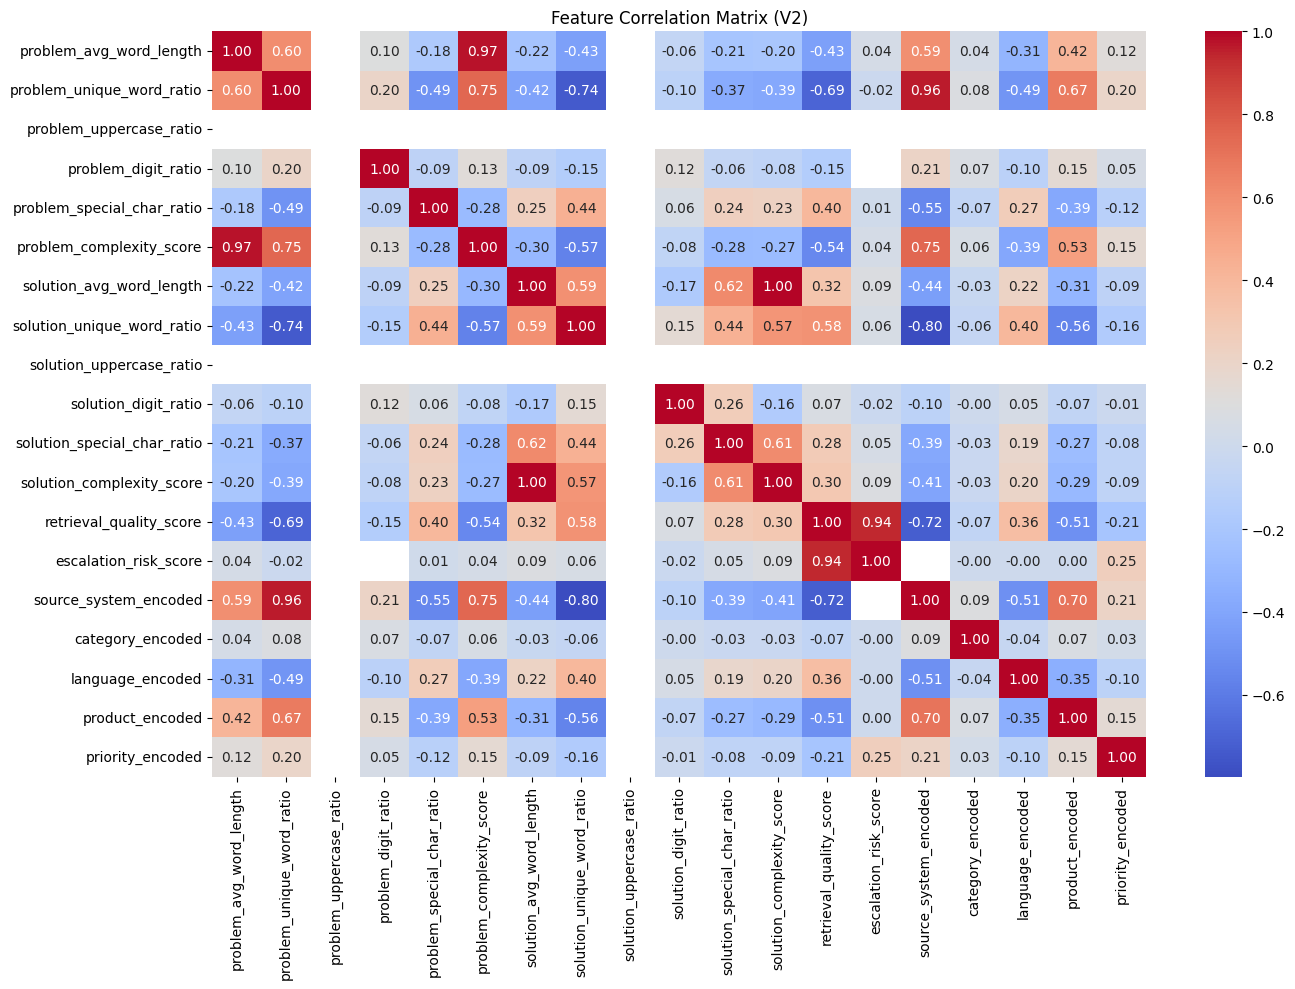

In [16]:
# ============================================================
# CELL 15 — FEATURE CORRELATION
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))

corr = df[FEATURE_COLUMNS].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix (V2)")

plt.tight_layout()
plt.show()


In [17]:
# ============================================================
# CELL 16 — TOP COMPLEX TICKETS
# ============================================================

top_complex = (
    df.sort_values(
        by="problem_complexity_score",
        ascending=False
    )
    .head(10)
)

print("=" * 60)
print("TOP COMPLEX TICKETS")
print("=" * 60)

display(
    top_complex[
        [
            "rag_id",
            "problem_complexity_score",
            "problem_text_clean"
        ]
    ]
)


TOP COMPLEX TICKETS


,rag_id,problem_complexity_score,problem_text_clean
5783,c16a33958b8a24d8f504ba08606d42a1,9.564667,istcstdintemicrosoftteams synchronisationvonpr...
42140,18676ed379e2bc42e9b4fb392ff98325,5.716000,fakturierungs-unstimmigkeiten das unternehmen ...
77816,5fa86a40acd0d0ff15ae6a536f4d70cb,5.484667,marketing-agentur widerspruch support beobacht...
51478,4b5ea26023fbc7722f2becf6fda4cbfa,5.403818,berichtsgenerierungs-system fehlermeldung fina...
29337,088472a0afba5859719e3f6f04898423,5.395778,verbessern von investment-analyse-tools optimi...
58110,a3b8912d2f5aaac0234715f8c9d5f0cd,5.380000,datensperre bei gesundheitsdienstleistern gesu...
31165,74daafebfcabb8441ca8fb2aaeedad09,5.278667,aktualisieren der datenanalyse-tools zur verbe...
42076,c960628d25acb62c80fe788d0c882bcd,5.266000,finanzanalyse-plattform dienststellungen beein...
91284,75305baf63e21ebf8a94e16f6d4b8e28,5.228000,datensperrungsverfahren bei gesundheitsdienstl...
41194,1f5a0f99128ec98154bdd21b4d92b933,5.216000,fehler bei investment-optimierung getreten heu...


In [18]:
# ============================================================
# CELL 17 — TOP RETRIEVAL QUALITY TICKETS
# ============================================================

top_quality = (
    df.sort_values(
        by="retrieval_quality_score",
        ascending=False
    )
    .head(10)
)

print("=" * 60)
print("TOP RETRIEVAL QUALITY TICKETS")
print("=" * 60)

display(
    top_quality[
        [
            "rag_id",
            "retrieval_quality_score",
            "problem_text_clean"
        ]
    ]
)


TOP RETRIEVAL QUALITY TICKETS


,rag_id,retrieval_quality_score,problem_text_clean
36763,0f5bb48b740b0fde0a732918b58d5343,4.225,two-factor authentication codes are not being ...
102933,7636d5b5525fdca851752c020d5c468b,4.225,i would like to request a refund for the recen...
38521,8f857e02f77e6212bfef5d9ab0850798,4.225,the application crashes whenever i try to uplo...
37141,3aa7ad012cbbae20111ba1e8a0e477d7,4.225,two-factor authentication codes are not being ...
21427,3d161709521b5a95802b331f71f13d6e,4.225,the system is not syncing data across devices ...
38040,8a3e4340ad1157092449ec6dd5b3ed29,4.225,there seems to be a discrepancy in my billing ...
83880,ff1b4a8f7203d8669675421bec8e7519,4.225,i am experiencing very slow performance while ...
83493,4c6ada03d183cdcf43d1dfddcc7a5b38,4.225,i am unable to access my account after enterin...
83512,acbb1cc71b8e918132c2761340e737ff,4.225,i would like to request a refund for the recen...
84079,a614a802cfd4ef850ac82d592e2805ba,4.225,i found a bug in the latest update affecting r...


In [19]:
# Cell 17B — all columns and types
print("All columns and types:")
for c in df.columns:
    sample = str(df[c].iloc[0])[:60]
    print(f"  {c} [{df[c].dtype}]: '{sample}'")

All columns and types:
  rag_id [str]: '45d0726cc395d2b3a2b8c9899523e1dc'
  problem_text_clean [str]: 'i am unable to access my account after entering the correct '
  solution_text_clean [str]: 'security settings updated and customer notified of precautio'
  category [str]: 'performance issue'
  priority [str]: 'critical'
  language [str]: 'french'
  product [str]: 'Subscription Service'
  queue [str]: 'nan'
  tag_1 [str]: 'nan'
  tag_2 [str]: 'nan'
  tag_3 [str]: 'nan'
  tag_4 [str]: 'nan'
  tag_5 [str]: 'nan'
  tag_6 [str]: 'nan'
  tag_7 [str]: 'nan'
  tag_8 [str]: 'nan'
  is_sla_breached [int64]: '1'
  is_escalated [int64]: '0'
  escalation_risk_level [str]: 'low'
  issue_complexity_score [float64]: '4.0'
  sla_risk_score [float64]: '3.75'
  problem_word_count [int64]: '24'
  problem_char_count [int64]: '145'
  problem_repetition_ratio [float64]: '0.5'
  solution_word_count [int64]: '9'
  solution_char_count [int64]: '74'
  solution_repetition_ratio [float64]: '0.0'
  source_system 

In [20]:
# ============================================================
# CELL 18 — FINAL FEATURE DATASET
# ============================================================

FINAL_FEATURE_COLUMNS = [
    c for c in [
        "document_id",
        "rag_id",
        "problem_text_clean",
        "solution_text_clean",
        "metadata_json",
        "source_system_encoded",
        "category_encoded",
        "language_encoded",
        "product_encoded",
        "priority_encoded",
        "problem_word_count",
        "problem_char_count",
        "problem_avg_word_length",
        "problem_unique_word_ratio",
        "problem_uppercase_ratio",
        "problem_digit_ratio",
        "problem_special_char_ratio",
        "problem_repetition_ratio",
        "problem_complexity_score",
        "solution_word_count",
        "solution_char_count",
        "solution_avg_word_length",
        "solution_unique_word_ratio",
        "solution_uppercase_ratio",
        "solution_digit_ratio",
        "solution_special_char_ratio",
        "solution_repetition_ratio",
        "solution_complexity_score",
        "retrieval_quality_score",
        "escalation_risk_score"
    ]
    if c in df.columns
]

feature_df = (
    df[FINAL_FEATURE_COLUMNS]
    .copy()
)

print("=" * 60)
print("FINAL FEATURE DATASET")
print("=" * 60)

print(f"Rows    : {len(feature_df):,}")
print(f"Columns : {feature_df.shape[1]}")

feature_df.head()


FINAL FEATURE DATASET
Rows    : 108,421
Columns : 30


,document_id,rag_id,problem_text_clean,solution_text_clean,metadata_json,source_system_encoded,category_encoded,language_encoded,product_encoded,priority_encoded,problem_word_count,problem_char_count,problem_avg_word_length,problem_unique_word_ratio,problem_uppercase_ratio,problem_digit_ratio,problem_special_char_ratio,problem_repetition_ratio,problem_complexity_score,solution_word_count,solution_char_count,solution_avg_word_length,solution_unique_word_ratio,solution_uppercase_ratio,solution_digit_ratio,solution_special_char_ratio,solution_repetition_ratio,solution_complexity_score,retrieval_quality_score,escalation_risk_score
0,doc_0,45d0726cc395d2b3a2b8c9899523e1dc,i am unable to access my account after enterin...,security settings updated and customer notifie...,"{""rag_id"": ""45d0726cc395d2b3a2b8c9899523e1dc"",...",0,8,4,8,0,24,145,5.083333,0.5,0.0,0.0,0.013793,0.5,2.281333,9,74,7.333333,1.0,0.0,0.0,0.013514,0.0,3.351333,2.3125,2.594900
1,doc_1,504f35fd3b03f048a1984f89fffb08e1,i would like to request a refund for the recen...,explained billing breakdown and clarified appl...,"{""rag_id"": ""504f35fd3b03f048a1984f89fffb08e1"",...",0,6,4,5,3,22,111,4.090909,0.5,0.0,0.0,0.018018,0.5,1.880364,7,61,7.857143,1.0,0.0,0.0,0.016393,0.0,3.556857,1.5750,2.625583
2,doc_2,db7bc1e2f75fa986ee832c31e320a2de,there seems to be a discrepancy in my billing ...,provided step-by-step troubleshooting instruct...,"{""rag_id"": ""db7bc1e2f75fa986ee832c31e320a2de"",...",0,10,3,4,1,26,143,4.538462,0.5,0.0,0.0,0.013986,0.5,2.067385,7,70,9.142857,1.0,0.0,0.0,0.042857,0.0,4.071143,3.1250,3.720779
3,doc_3,01d7f2addbcc200f88368695230ea06e,the system is not syncing data across devices ...,bug logged internally and workaround shared wi...,"{""rag_id"": ""01d7f2addbcc200f88368695230ea06e"",...",0,7,0,1,2,18,111,5.222222,0.5,0.0,0.0,0.018018,0.5,2.324889,9,62,6.000000,1.0,0.0,0.0,0.016129,0.0,2.818000,2.6125,3.361433
4,doc_4,aa219338e9e467aadb53d3d1a9026de7,i am unable to access my account after enterin...,provided step-by-step troubleshooting instruct...,"{""rag_id"": ""aa219338e9e467aadb53d3d1a9026de7"",...",0,12,5,4,2,24,145,5.083333,0.5,0.0,0.0,0.013793,0.5,2.281333,7,70,9.142857,1.0,0.0,0.0,0.042857,0.0,4.071143,2.9500,3.862871


In [21]:
# ============================================================
# CELL 19 — EXPORT FEATURE DATASET
# ============================================================

EXPORT_PATH = "../../parquet_exports_v2/feature_engineered_v2.parquet"

feature_df.to_parquet(
    EXPORT_PATH,
    index=False
)

print("=" * 60)
print("FEATURE DATASET EXPORTED")
print("=" * 60)

print(f"Export Path:\n{EXPORT_PATH}")


FEATURE DATASET EXPORTED
Export Path:
../../parquet_exports_v2/feature_engineered_v2.parquet


In [22]:
# ============================================================
# CELL 20 — EXPORT FEATURE SAMPLE
# ============================================================

SAMPLE_EXPORT = "../../evaluation_v2/feature_dataset_sample_v2.csv"

feature_df.head(100).to_csv(
    SAMPLE_EXPORT,
    index=False
)

print(f"Sample exported to:\n{SAMPLE_EXPORT}")


Sample exported to:
../../evaluation_v2/feature_dataset_sample_v2.csv


In [23]:
# ============================================================
# CELL 21 — FINAL FEATURE HEALTH REPORT
# ============================================================

print("=" * 60)
print("FINAL FEATURE HEALTH REPORT")
print("=" * 60)

print(f"Total Rows                 : {len(feature_df):,}")
print(f"Total Features             : {feature_df.shape[1]}")
print(f"Average Problem Complexity : {feature_df['problem_complexity_score'].mean():.4f}")
print(f"Average Solution Complexity: {feature_df['solution_complexity_score'].mean():.4f}")
print(f"Average Retrieval Quality  : {feature_df['retrieval_quality_score'].mean():.4f}")
print(f"Average Escalation Risk    : {feature_df['escalation_risk_score'].mean():.4f}")

if "source_system_encoded" in feature_df.columns:
    print(f"Unique Source Systems      : {feature_df['source_system_encoded'].nunique()}")

if "category_encoded" in feature_df.columns:
    print(f"Unique Categories          : {feature_df['category_encoded'].nunique()}")

if "language_encoded" in feature_df.columns:
    print(f"Unique Languages           : {feature_df['language_encoded'].nunique()}")

if "product_encoded" in feature_df.columns:
    print(f"Unique Products            : {feature_df['product_encoded'].nunique()}")


FINAL FEATURE HEALTH REPORT
Total Rows                 : 108,421
Total Features             : 30
Average Problem Complexity : 2.4446
Average Solution Complexity: 3.0066
Average Retrieval Quality  : 2.1627
Average Escalation Risk    : 3.2711
Unique Source Systems      : 2
Unique Categories          : 14
Unique Languages           : 8
Unique Products            : 11
